In [52]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
results = pd.read_csv('./evaluation_results/eval_results_2025-12-18_21-28-51.csv')


In [54]:
import json

evaluation_questions_and_answers = json.loads(open("questions_answers.json", "r", encoding="utf-8").read())
prepared_qa = []

for qa_pair in evaluation_questions_and_answers:
    prepared_qa.append({
        "question": qa_pair["question"]["nl"],
        "ground_truth": qa_pair["ground_truth"]["nl"],
        "project": qa_pair["project"],
        "language": "nl",
        "filename": qa_pair["filename"],
        "specificity": qa_pair["specificity"],
        "original_language": qa_pair["original_language"],
    })
    prepared_qa.append({
        "question": qa_pair["question"]["en"],
        "ground_truth": qa_pair["ground_truth"]["en"],
        "project": qa_pair["project"],
        "language": "en",
        "filename": qa_pair["filename"],
        "specificity": qa_pair["specificity"],
        "original_language": qa_pair["original_language"],
        "author": qa_pair["author"]
    })

for i, row in results.iterrows():
    question = row["question"]
    
    matches = next((item for item in prepared_qa if item["question"] == question), None)
    if matches:
        results.at[i, "original_language"] = matches["original_language"]
        results.at[i, "author"] = matches["author"]
    else:
        print(f"No match found for question: {question}")

No match found for question: For which types of wastewaters is anaerobic treatment most convenient?
No match found for question: For which types of wastewaters is anaerobic treatment most convenient?


In [55]:
for i, row in results.iterrows():
  print(f'qa pair {i}:')
  print('question:')
  print(row['question'])
  print()
  print('ground truth:')
  print(row['ground_truth'])
  print()
  print('generated output:')
  print(row['model_output'])
  print('________________________________________________________________________________________________________________________________________________________')

qa pair 0:
question:
What is the tradeoff when using MD compared to RO?

ground truth:
MD gives higher product quality with no additional post-treatment, but is very energy intensive and produces a small product flow. RO is more water-efficient and economically favorable but may require additional treatment to meet specifications.

generated output:
Based on the provided context, there doesn't seem to be any comparison between "MD" and "RO". The term "MD" isn't defined in this conversation. Therefore, I'm unable to provide an answer regarding a tradeoff between these two concepts. 

If you could please clarify what specific aspects or characteristics of MD and RO are being compared (e.g., cost, performance, application areas), that would help me give a more accurate response based on the available information.
________________________________________________________________________________________________________________________________________________________
qa pair 1:
question:
What

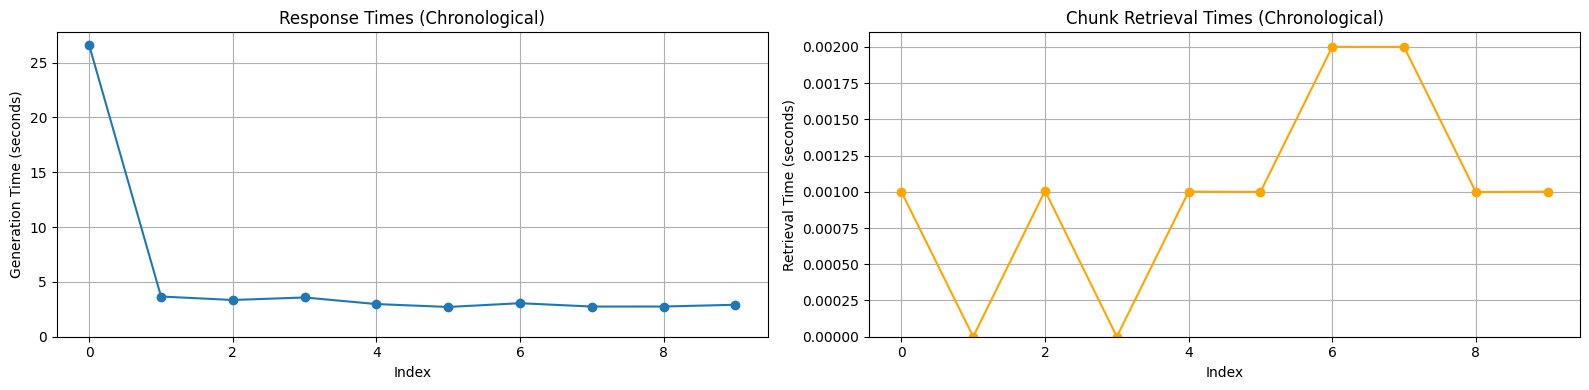

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharex=True)

axes[0].plot(results.index, results['generation_time'], marker='o', label='Generation Time')
axes[0].set_title('Response Times (Chronological)')
axes[0].set_xlabel('Index')
axes[0].set_ylabel('Generation Time (seconds)')
axes[0].set_ylim(0)
axes[0].grid(True)

axes[1].plot(results.index, results['chunk_retrieval_time'], marker='o', color='orange', label='Retrieval Time')
axes[1].set_title('Chunk Retrieval Times (Chronological)')
axes[1].set_xlabel('Index')
axes[1].set_ylabel('Retrieval Time (seconds)')
axes[1].set_ylim(0)
axes[1].grid(True)

plt.tight_layout()
plt.show()

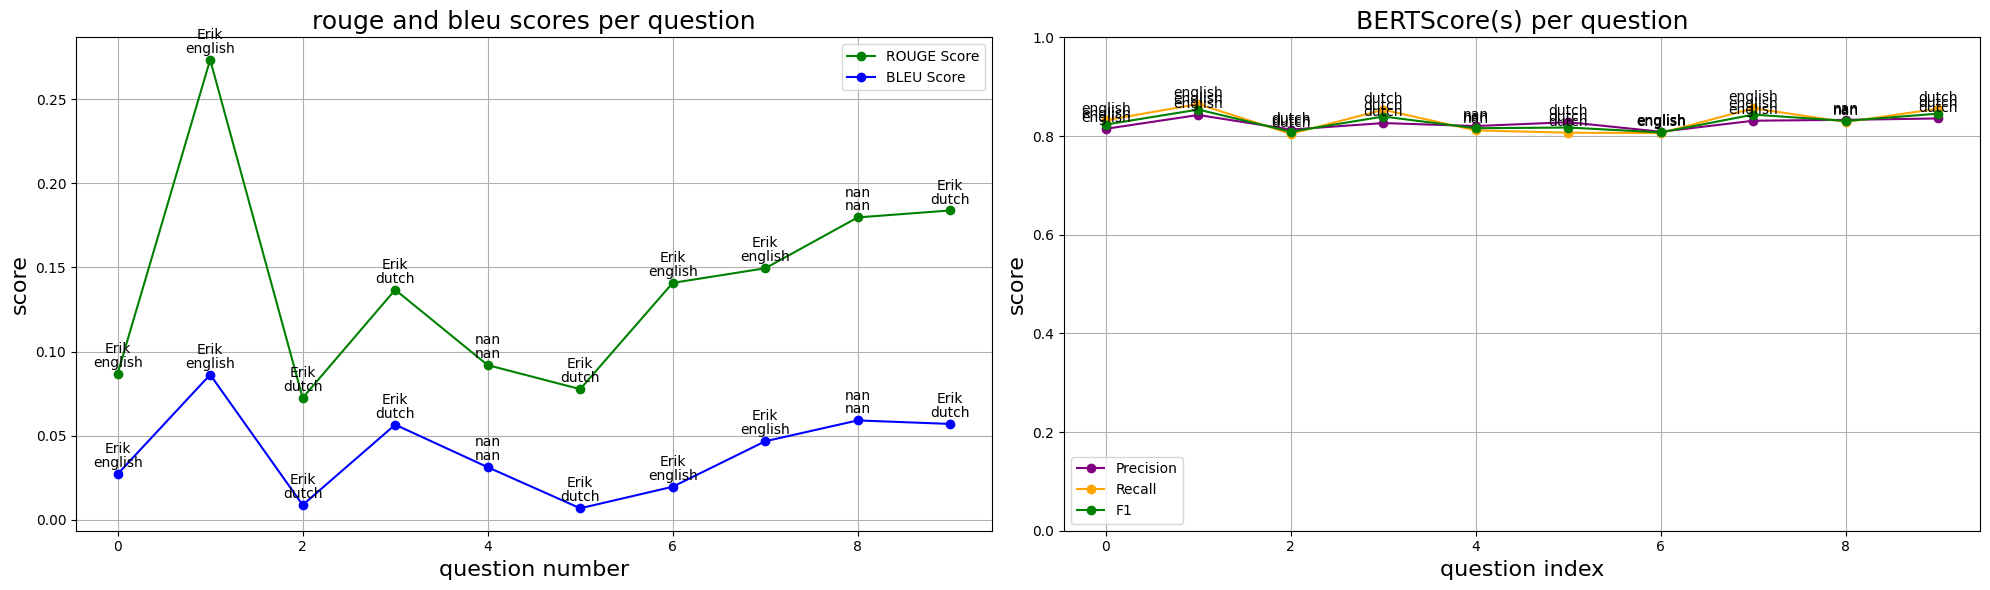

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

axes[0].plot(results.index, results['rouge'], marker='o', label='ROUGE Score', color='green')
axes[0].plot(results.index, results['bleu'], marker='o', label='BLEU Score', color='blue')
axes[0].set_title('rouge and bleu scores per question', fontsize=18)
axes[0].set_xlabel('question number', fontsize=16)
axes[0].set_ylabel('score', fontsize=16)
axes[0].legend()
axes[0].grid(True)

# Add text above each point for the first plot
for i, txt in enumerate(results['original_language']):
  axes[0].annotate(txt, (results.index[i], results['rouge'][i]), textcoords="offset points", xytext=(0, 5), ha='center')
  axes[0].annotate(txt, (results.index[i], results['bleu'][i]), textcoords="offset points", xytext=(0, 5), ha='center')

for i, txt in enumerate(results['author']):
  axes[0].annotate(txt, (results.index[i], results['rouge'][i]), textcoords="offset points", xytext=(0, 15), ha='center')
  axes[0].annotate(txt, (results.index[i], results['bleu'][i]), textcoords="offset points", xytext=(0, 15), ha='center')

results['precision'] = results['precision'].apply(lambda x: float(str(x).strip("tensor([])")))
results['recall'] = results['recall'].apply(lambda x: float(str(x).strip("tensor([])")))
results['F1'] = results['F1'].apply(lambda x: float(str(x).strip("tensor([])")))
axes[1].plot(results.index, results['precision'], marker='o', label='Precision', color='purple')
axes[1].plot(results.index, results['recall'], marker='o', label='Recall', color='orange')
axes[1].plot(results.index, results['F1'], marker='o', label='F1', color='green')
axes[1].set_title('BERTScore(s) per question', fontsize=18)
axes[1].set_xlabel('question index', fontsize=16)
axes[1].set_ylabel('score', fontsize=16)
axes[1].legend()
axes[1].grid(True)
axes[1].set_ylim(0, 1)

# Add text above each point for the second plot
for i, txt in enumerate(results['original_language']):
  axes[1].annotate(txt, (results.index[i], results['precision'][i]), textcoords="offset points", xytext=(0, 5), ha='center')
  axes[1].annotate(txt, (results.index[i], results['recall'][i]), textcoords="offset points", xytext=(0, 5), ha='center')
  axes[1].annotate(txt, (results.index[i], results['F1'][i]), textcoords="offset points", xytext=(0, 5), ha='center')

plt.tight_layout()
plt.show()

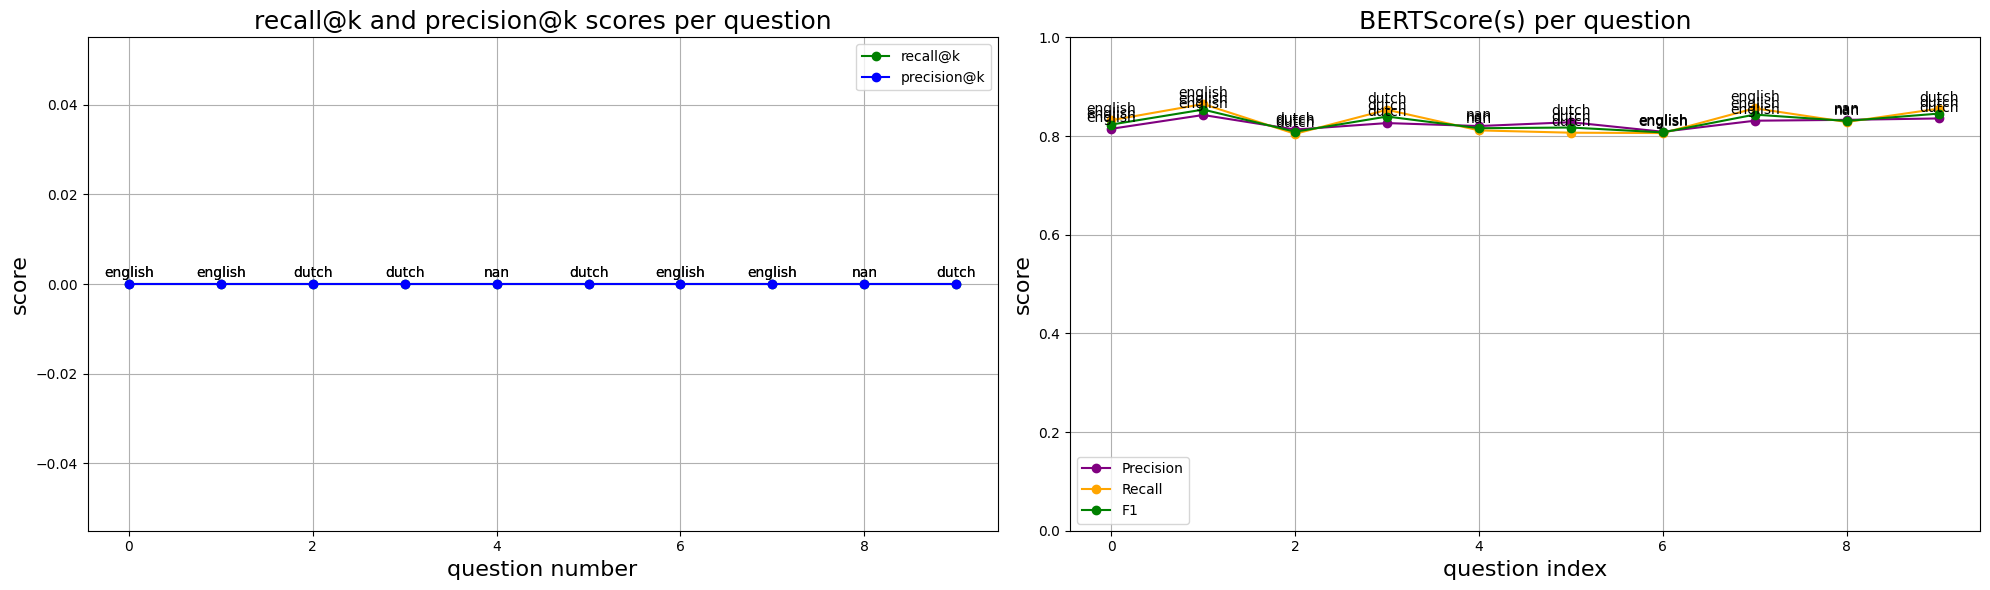

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

axes[0].plot(results.index, results['recall@k'], marker='o', label='recall@k', color='green')
axes[0].plot(results.index, results['precision@k'], marker='o', label='precision@k', color='blue')
axes[0].set_title('recall@k and precision@k scores per question', fontsize=18)
axes[0].set_xlabel('question number', fontsize=16)
axes[0].set_ylabel('score', fontsize=16)
axes[0].legend()
axes[0].grid(True)

# Add text above each point for the first plot
for i, txt in enumerate(results['original_language']):
  axes[0].annotate(txt, (results.index[i], results['recall@k'][i]), textcoords="offset points", xytext=(0, 5), ha='center')
  axes[0].annotate(txt, (results.index[i], results['precision@k'][i]), textcoords="offset points", xytext=(0, 5), ha='center')

results['precision'] = results['precision'].apply(lambda x: float(str(x).strip("tensor([])")))
results['recall'] = results['recall'].apply(lambda x: float(str(x).strip("tensor([])")))
results['F1'] = results['F1'].apply(lambda x: float(str(x).strip("tensor([])")))
axes[1].plot(results.index, results['precision'], marker='o', label='Precision', color='purple')
axes[1].plot(results.index, results['recall'], marker='o', label='Recall', color='orange')
axes[1].plot(results.index, results['F1'], marker='o', label='F1', color='green')
axes[1].set_title('BERTScore(s) per question', fontsize=18)
axes[1].set_xlabel('question index', fontsize=16)
axes[1].set_ylabel('score', fontsize=16)
axes[1].legend()
axes[1].grid(True)
axes[1].set_ylim(0, 1)

# Add text above each point for the second plot
for i, txt in enumerate(results['original_language']):
  axes[1].annotate(txt, (results.index[i], results['precision'][i]), textcoords="offset points", xytext=(0, 5), ha='center')
  axes[1].annotate(txt, (results.index[i], results['recall'][i]), textcoords="offset points", xytext=(0, 5), ha='center')
  axes[1].annotate(txt, (results.index[i], results['F1'][i]), textcoords="offset points", xytext=(0, 5), ha='center')

plt.tight_layout()
plt.show()

In [59]:
averages = results.mean(numeric_only=True)
print(averages)

chunk_retrieval_time    0.001000
generation_time         5.433722
bleu                    0.039923
rouge                   0.139336
precision               0.825270
recall                  0.831850
F1                      0.828470
recall@k                0.000000
precision@k             0.000000
dtype: float64


first prompt:

chunk_retrieval_time     0.020129 -> 0.023403

generation_time         60.685850 -> 76.223767

bleu                     0.033003 -> 0.128261

rouge                    0.125113 -> 0.222738

precision                0.812940 -> 0.833550

recall                   0.859570 -> 0.862730

recall@k                 0.900000 -> 0.80000

precision@k              0.640000 -> 0.46000

dtype: float64

5 chunks retrieved using english query

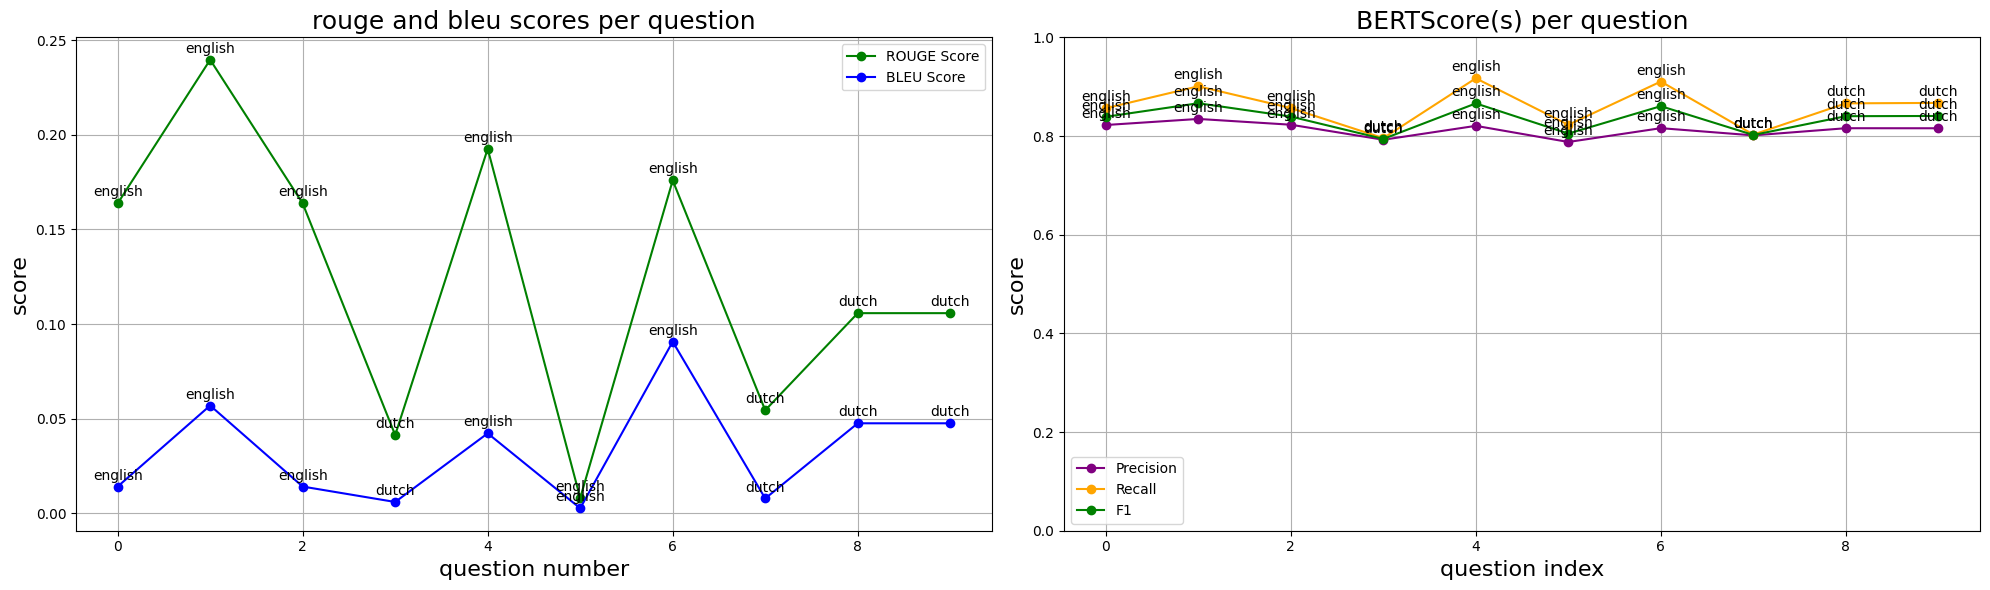


3 chunks retrieved using english query, and 3 chunks retrieved using translated dutch alternative

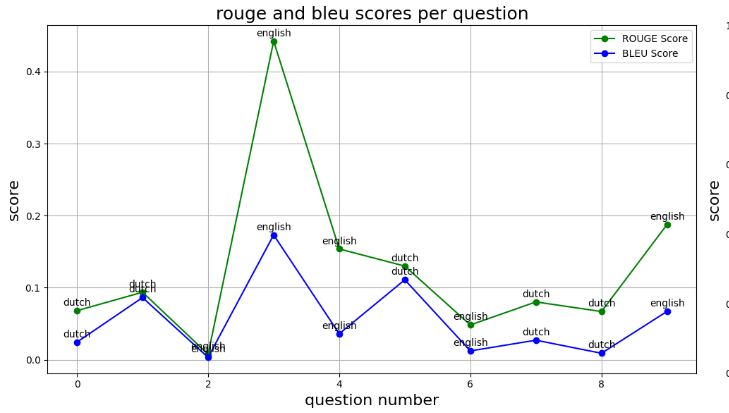

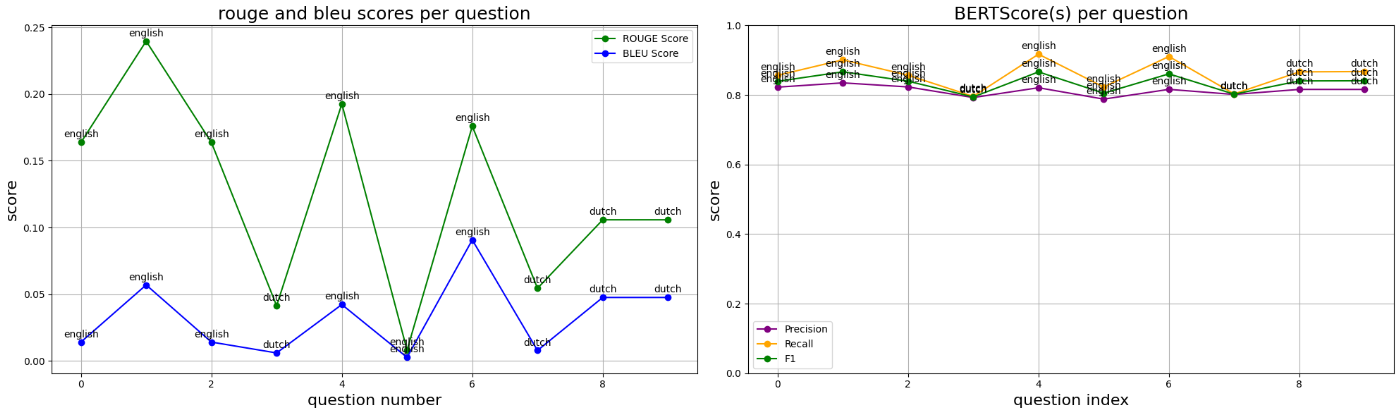